In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [6]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

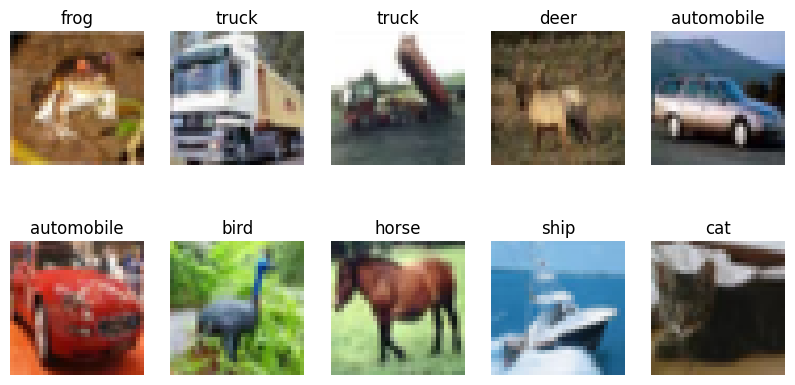

In [8]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [9]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 43ms/step - accuracy: 0.4537 - loss: 1.4952 - val_accuracy: 0.5650 - val_loss: 1.2370
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.5936 - loss: 1.1457 - val_accuracy: 0.6333 - val_loss: 1.0323
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6557 - loss: 0.9789 - val_accuracy: 0.6260 - val_loss: 1.0652
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.6964 - loss: 0.8647 - val_accuracy: 0.6866 - val_loss: 0.9057
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 42ms/step - accuracy: 0.7245 - loss: 0.7878 - val_accuracy: 0.7080 - val_loss: 0.8480
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7465 - loss: 0.7227 - val_accuracy: 0.7081 - val_loss: 0.8562
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.7648 - loss: 0.6674 - val_accuracy: 0.7138 - val_loss: 0.8319
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7823 -

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7007 - loss: 0.9336
Test Accuracy: 0.7006999850273132


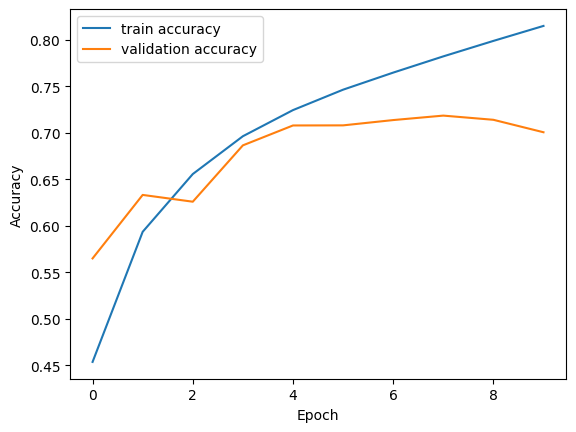

In [13]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


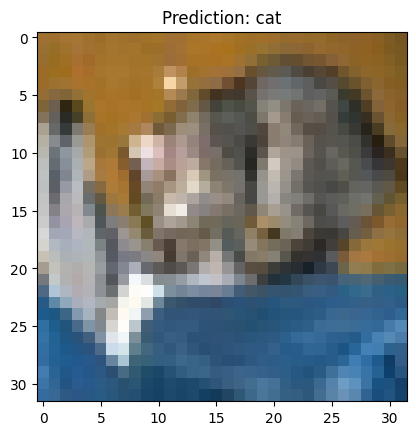

In [14]:
prediction = model.predict(x_test)

predicted_class = np.argmax(prediction[0])

plt.imshow(x_test[0])
plt.title("Prediction: " + class_names[predicted_class])
plt.show()